# Training và đánh giá mô hình
1. Chọn các đặc trưng quan trọng bằng Univariable Logistic Regression -> VIF -> Multivariable Logistic Regression
2. Huấn luyện LR: Dùng Hyperopt để chọn tham số tốt nhất trên tập train -> Fit lại model trên tập train
3. Đánh giá LR: Test trên tập internal và external, gồm các metrics AUC, Precision, Recall, F1-score
4. Đánh giá tính explanability bằng SHAP + Odds Ratio

# Import thư viện

In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score, 
                           precision_score, f1_score, roc_auc_score, brier_score_loss, confusion_matrix, precision_recall_curve, auc)
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from hyperopt import fmin, tpe, hp, STATUS_OK, STATUS_FAIL, space_eval, Trials
from functools import partial
import warnings
import os
import json
from sklearn.utils import resample
warnings.filterwarnings('ignore')

# 1. Load dữ liệu

In [17]:
train_file = "AKI_dataset/train.csv"
test_files = {
    'internal_MIMIC': "AKI_dataset/test_internal_MIMIC.csv",
    'external': "AKI_dataset/test_external.csv"
}

train = pd.read_csv(train_file)
if "Unnamed: 0" in train.columns:
    train = train.drop(columns=["Unnamed: 0"])

y_train = train["aki_label"]

ids_to_drop = ["subject_id", "patientunitstayid", "hadm_id", "stay_id"]
drop_cols_train = ["aki_label"] + [c for c in ids_to_drop if c in train.columns]
X_train = train.drop(columns=drop_cols_train)

X_test_dict = {}
y_test_dict = {}
test_ids_dict = {}

for test_name, filepath in test_files.items():
    test = pd.read_csv(filepath)
    if "Unnamed: 0" in test.columns:
        test = test.drop(columns=["Unnamed: 0"])
        
    y_test_dict[test_name] = test["aki_label"]
    
    if "subject_id" in test.columns:
        test_ids_dict[test_name] = test["subject_id"]
    elif "patientunitstayid" in test.columns:
        test_ids_dict[test_name] = test["patientunitstayid"]
    else:
        test_ids_dict[test_name] = np.arange(len(test))
        
    drop_cols_test = ["aki_label"] + [c for c in ids_to_drop if c in test.columns]
    X_test_dict[test_name] = test.drop(columns=drop_cols_test)

print(f"Loaded successfully: X_train={X_train.shape}")
for name, df in X_test_dict.items():
    print(f"  - X_test_{name} = {df.shape}")

Loaded successfully: X_train=(1852, 33)
  - X_test_internal_MIMIC = (464, 33)
  - X_test_external = (7908, 33)


# 2. Feature Selection

In [18]:
print("  - Chạy Univariable LR...")
selected_univariable = []
for col in X_train.columns:
    try:
        X_temp = sm.add_constant(X_train[col])
        model = sm.Logit(y_train, X_temp).fit(disp=False)
        if model.pvalues[col] < 0.05:
            selected_univariable.append(col)
    except Exception:
        pass
        
print(f"    -> Giữ lại {len(selected_univariable)} / {len(X_train.columns)} biến có p < 0.05.")
X_train_fs = X_train[selected_univariable].copy()

print("  - Chạy VIF threshold 10...")
while len(X_train_fs.columns) > 0:
    X_vif = sm.add_constant(X_train_fs)
    vif_values = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    
    vif_series = pd.Series(vif_values, index=X_vif.columns).drop('const', errors='ignore')
    
    if vif_series.empty:
        break
        
    max_vif = vif_series.max()
    if max_vif >= 10:
        removed_col = vif_series.idxmax()
        X_train_fs = X_train_fs.drop(columns=[removed_col])
    else:
        break
        
selected_vif = X_train_fs.columns.tolist()
print(f"    -> Giữ lại {len(selected_vif)} biến có VIF < 10.")

print("  - Chạy Multivariable LR...")
selected_final = []
try:
    if len(selected_vif) > 0:
        X_multi = sm.add_constant(X_train_fs)
        model_multi = sm.Logit(y_train, X_multi).fit(disp=False)
        p_values = model_multi.pvalues.drop('const', errors='ignore')
        selected_final = p_values[p_values < 0.05].index.tolist()
except Exception as e:
    print(f"  [Warning] Lỗi khi chạy Multivariable LR, dùng kết quả sau VIF. Chi tiết: {e}")
    selected_final = selected_vif

if len(selected_final) == 0:
    print("  [Warning] Không có biến nào vượt qua được vòng selection. Lấy toàn bộ biến sau VIF.")
    selected_final = selected_vif

print(f"    -> Giữ lại {len(selected_final)} biến cuối cùng.")

X_train = X_train[selected_final]
for test_name in X_test_dict.keys():
    X_test_dict[test_name] = X_test_dict[test_name][selected_final]

out_dir = "external_results"
os.makedirs(out_dir, exist_ok=True)

feature_selection_dict = {
    "univariable_features": selected_univariable,
    "after_vif_features": selected_vif,
    "final_selected_features": selected_final,
    "n_univariable": len(selected_univariable),
    "n_after_vif": len(selected_vif),
    "n_final": len(selected_final)
}

fs_json_path = os.path.join(out_dir, "feature_selection_results.json")
with open(fs_json_path, 'w', encoding='utf-8') as f:
    json.dump(feature_selection_dict, f, indent=4, ensure_ascii=False)

  - Chạy Univariable LR...
    -> Giữ lại 24 / 33 biến có p < 0.05.
  - Chạy VIF threshold 10...
    -> Giữ lại 22 biến có VIF < 10.
  - Chạy Multivariable LR...
    -> Giữ lại 11 biến cuối cùng.


# 3. Training

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("\n=== Optimizing & Training LogisticRegression ===")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": np.logspace(-3, 2, 10),
        "max_iter": [1000, 2000, 5000]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": np.logspace(-3, 2, 10),
        "max_iter": [1000, 2000, 5000]
    }
]

base_estimator = LogisticRegression(class_weight="balanced", random_state=42)
grid = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

lr_params = grid.best_params_
print(f"Best params found: {lr_params}")

print("Fitting final model...")
lr_model = grid.best_estimator_


=== Optimizing & Training LogisticRegression ===
Best params found: {'C': 75.85766819379519, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}
Fitting final model...


,penalty,'l1'
,dual,False
,tol,0.0001
,C,75.85766819379519
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,2000
,multi_class,'deprecated'


# 4. Đánh giá mô hình

In [20]:
out_dir = "external_results"
os.makedirs(out_dir, exist_ok=True)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

for test_name, X_test in X_test_dict.items():
    y_test = y_test_dict[test_name]
    test_ids = test_ids_dict[test_name]
    
    print(f"\n{'='*60}")
    print(f"=== ĐÁNH GIÁ TRÊN TẬP: {test_name.upper()} ===")
    print(f"{'='*60}")
    
    y_prob = lr_model.predict_proba(X_test)[:, 1]
    custom_threshold = 0.3
    y_pred = (y_prob >= custom_threshold).astype(int)

    # --- Tính Point Estimates ---
    acc_pt          = accuracy_score(y_test, y_pred)
    balanced_acc_pt = balanced_accuracy_score(y_test, y_pred)
    recall_pt       = recall_score(y_test, y_pred)
    precision_pt    = precision_score(y_test, y_pred, zero_division=0)
    f1_pt           = f1_score(y_test, y_pred)
    roc_auc_pt      = roc_auc_score(y_test, y_prob)
    spec_pt         = specificity_score(y_test, y_pred)
    precision_pts, recall_pts, _ = precision_recall_curve(y_test, y_prob)
    auprc_pt        = auc(recall_pts, precision_pts)
    brier_pt        = brier_score_loss(y_test, y_prob)

    # --- Thực hiện Bootstrapping 1000 lần tính CI 95% ---
    print(f"Đang chạy Bootstrapping tính CI 95% ({test_name})...")
    n_iterations = 1000
    bootstrapped_scores = {
        'acc': [], 'balanced_acc': [], 'spec': [], 'precision': [], 
        'recall': [], 'f1': [], 'roc_auc': [], 'auprc': [], 'brier': []
    }

    indices = np.arange(len(y_test))
    y_test_arr = y_test.values if isinstance(y_test, pd.Series) else y_test

    for i in range(n_iterations):
        boot_indices = resample(indices, replace=True, n_samples=len(indices), random_state=i)
        y_test_boot = y_test_arr[boot_indices]
        y_prob_boot = y_prob[boot_indices]
        y_pred_boot = y_pred[boot_indices]
        
        if len(np.unique(y_test_boot)) < 2:
            continue
            
        bootstrapped_scores['acc'].append(accuracy_score(y_test_boot, y_pred_boot))
        bootstrapped_scores['balanced_acc'].append(balanced_accuracy_score(y_test_boot, y_pred_boot))
        bootstrapped_scores['spec'].append(specificity_score(y_test_boot, y_pred_boot))
        bootstrapped_scores['precision'].append(precision_score(y_test_boot, y_pred_boot, zero_division=0))
        bootstrapped_scores['recall'].append(recall_score(y_test_boot, y_pred_boot))
        bootstrapped_scores['f1'].append(f1_score(y_test_boot, y_pred_boot))
        bootstrapped_scores['roc_auc'].append(roc_auc_score(y_test_boot, y_prob_boot))
        
        p_pts, r_pts, _ = precision_recall_curve(y_test_boot, y_prob_boot)
        bootstrapped_scores['auprc'].append(auc(r_pts, p_pts))
        bootstrapped_scores['brier'].append(brier_score_loss(y_test_boot, y_prob_boot))

    ci = {metric: (np.percentile(scores, 2.5), np.percentile(scores, 97.5)) for metric, scores in bootstrapped_scores.items()}

    print(f"\n--- KẾT QUẢ {test_name.upper()} (POINT ESTIMATE [95% CI]) ---")
    print(f" Accuracy          : {acc_pt:.4f} [{ci['acc'][0]:.4f} - {ci['acc'][1]:.4f}]")
    print(f" Precision         : {precision_pt:.4f} [{ci['precision'][0]:.4f} - {ci['precision'][1]:.4f}]")
    print(f" Recall            : {recall_pt:.4f} [{ci['recall'][0]:.4f} - {ci['recall'][1]:.4f}]")
    print(f" F1-Score          : {f1_pt:.4f} [{ci['f1'][0]:.4f} - {ci['f1'][1]:.4f}]")
    print(f" ROC AUC           : {roc_auc_pt:.4f} [{ci['roc_auc'][0]:.4f} - {ci['roc_auc'][1]:.4f}]")

    # Lưu Prediction Results
    curr_pred_df = pd.DataFrame({
        'subject_id': np.array(test_ids),
        'True_Label': y_test_arr,
        'Prob_Model': y_prob,
        'Predicted_Label': y_pred,
        'cutoff_threshold': custom_threshold,
        'Model': "Logistic Regression"
    })
    
    out_path = os.path.join(out_dir, f"LR_prediction_results_{test_name}.csv")
    curr_pred_df.to_csv(out_path, index=False)
    
    # Lưu Lỗi Dự Đoán
    errors_mask = y_pred != y_test_arr
    errors_indices = np.where(errors_mask)[0]
    errors_df = pd.DataFrame({
        'subject_id': np.array(test_ids)[errors_indices],
        'predicted': y_pred[errors_indices],
        'label': y_test_arr[errors_indices]
    })
    
    errors_output_path = os.path.join(out_dir, f"LR_prediction_errors_{test_name}.csv")
    errors_df.to_csv(errors_output_path, index=False)
    print(f"[{test_name}] Đã xuất các file:\n > {out_path}\n > {errors_output_path}")


=== ĐÁNH GIÁ TRÊN TẬP: INTERNAL_MIMIC ===
Đang chạy Bootstrapping tính CI 95% (internal_MIMIC)...

--- KẾT QUẢ INTERNAL_MIMIC (POINT ESTIMATE [95% CI]) ---
 Accuracy          : 0.6638 [0.6206 - 0.7048]
 Precision         : 0.6759 [0.6285 - 0.7206]
 Recall            : 0.9088 [0.8750 - 0.9379]
 F1-Score          : 0.7752 [0.7401 - 0.8083]
 ROC AUC           : 0.6906 [0.6403 - 0.7417]
[internal_MIMIC] Đã xuất các file:
 > external_results/LR_prediction_results_internal_MIMIC.csv
 > external_results/LR_prediction_errors_internal_MIMIC.csv

=== ĐÁNH GIÁ TRÊN TẬP: EXTERNAL ===
Đang chạy Bootstrapping tính CI 95% (external)...

--- KẾT QUẢ EXTERNAL (POINT ESTIMATE [95% CI]) ---
 Accuracy          : 0.6155 [0.6048 - 0.6257]
 Precision         : 0.5932 [0.5811 - 0.6052]
 Recall            : 0.8861 [0.8763 - 0.8951]
 F1-Score          : 0.7107 [0.7012 - 0.7201]
 ROC AUC           : 0.7135 [0.7033 - 0.7241]
[external] Đã xuất các file:
 > external_results/LR_prediction_results_external.csv
 > e

# 5. Diễn giải mô hình

SHAP values

=== Global Feature Importance: internal_MIMIC ===


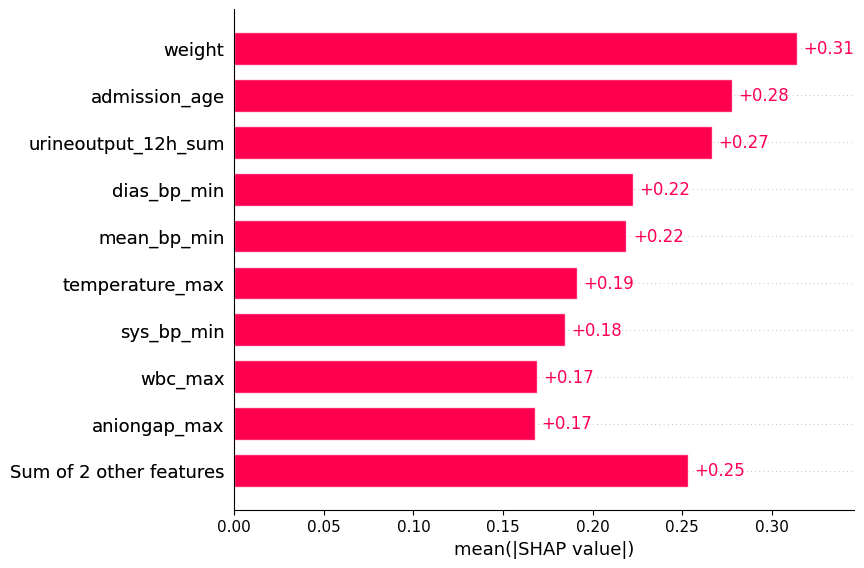

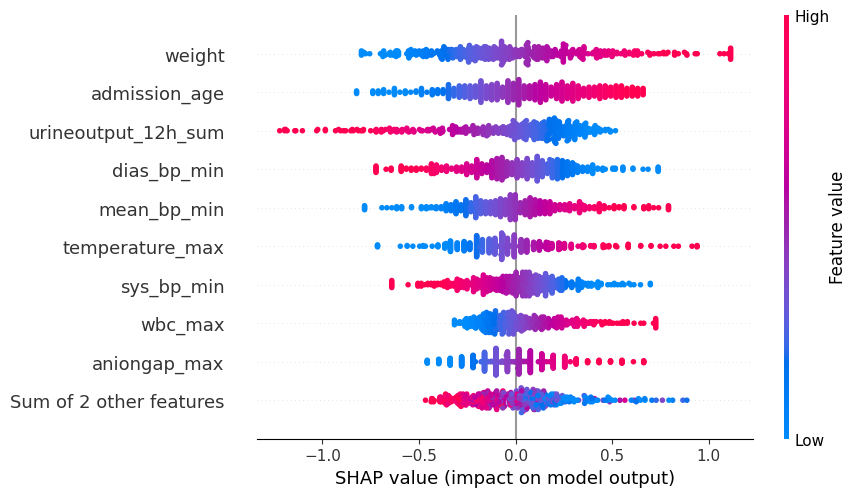

=== Global Feature Importance: external ===


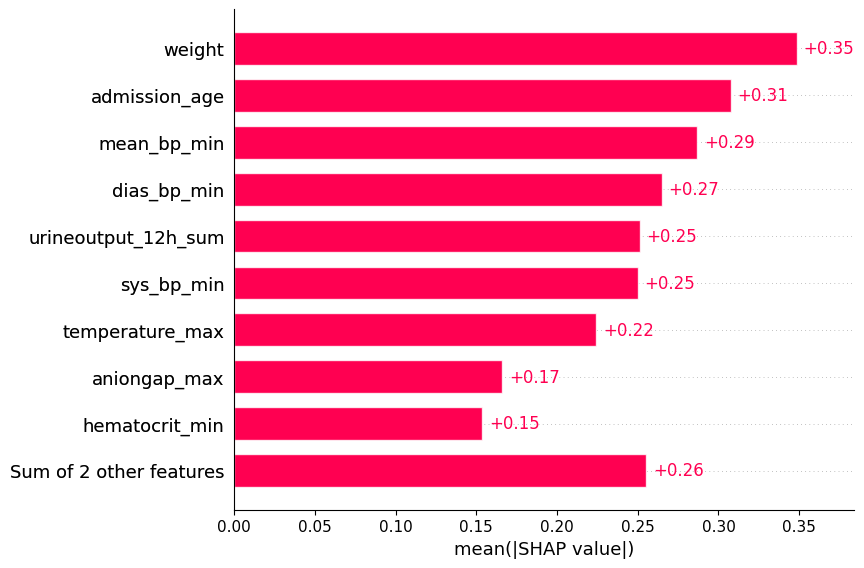

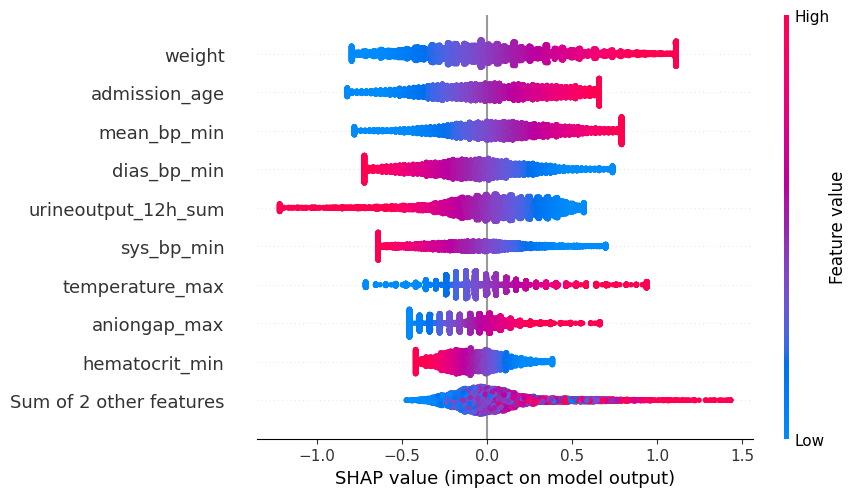

In [21]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(lr_model, X_train)

for test_name, X_test in X_test_dict.items():
    print(f"=== Global Feature Importance: {test_name} ===")
    shap_values = explainer(X_test)

    shap.plots.bar(shap_values)
    shap.plots.beeswarm(shap_values)

Odds Ratio

In [22]:
# Fit lại mô hình với các biến cuối cùng
X_train_final_sm = sm.add_constant(X_train)
final_sm_model = sm.Logit(y_train, X_train_final_sm).fit(disp=False)

# Tính Odds Ratio và 95% CI cho OR
conf = final_sm_model.conf_int()
conf['OR'] = final_sm_model.params
conf.columns = ['2.5%', '97.5%', 'OR']
or_df = np.exp(conf)

results_df = pd.DataFrame({
    'Predictor': final_sm_model.params.index,
    'β': final_sm_model.params.values,
    'SE': final_sm_model.bse.values,
    'z value': final_sm_model.tvalues.values,
    'p-value': final_sm_model.pvalues.values,
    'OR': or_df['OR'].values,
    'OR 2.5%': or_df['2.5%'].values,
    'OR 97.5%': or_df['97.5%'].values
})

# Làm tròn
results_df['p-value'] = results_df['p-value'].apply(lambda x: f"{x:.4f}")
results_df['β'] = results_df['β'].apply(lambda x: f"{x:.4f}")
results_df['SE'] = results_df['SE'].apply(lambda x: f"{x:.4f}")
results_df['z value'] = results_df['z value'].apply(lambda x: f"{x:.4f}")
results_df['OR (95% CI)'] = results_df.apply(lambda row: f"{row['OR']:.4f} ({row['OR 2.5%']:.4f} - {row['OR 97.5%']:.4f})", axis=1)
results_df['Predictor'] = results_df['Predictor'].replace({'const': 'Intercept'})
final_table = results_df[['Predictor', 'β', 'SE', 'z value', 'p-value', 'OR (95% CI)']]
print(final_table.to_string(index=False))

          Predictor       β     SE z value p-value              OR (95% CI)
          Intercept  0.6589 0.0530 12.4402  0.0000 1.9326 (1.7421 - 2.1440)
      admission_age  0.3416 0.0619  5.5222  0.0000 1.4073 (1.2466 - 1.5887)
             weight  0.3758 0.0599  6.2713  0.0000 1.4561 (1.2948 - 1.6375)
         sys_bp_min -0.2428 0.0775 -3.1309  0.0017 0.7845 (0.6739 - 0.9132)
        mean_bp_min  0.2677 0.1183  2.2630  0.0236 1.3069 (1.0365 - 1.6479)
        dias_bp_min -0.2658 0.1046 -2.5410  0.0111 0.7666 (0.6245 - 0.9410)
    temperature_max  0.2696 0.0569  4.7377  0.0000 1.3094 (1.1712 - 1.4638)
     creatinine_min  0.1532 0.0629  2.4361  0.0148 1.1656 (1.0304 - 1.3186)
       aniongap_max  0.2261 0.0612  3.6944  0.0002 1.2536 (1.1120 - 1.4134)
urineoutput_12h_sum -0.3558 0.0534 -6.6604  0.0000 0.7006 (0.6310 - 0.7780)
     hematocrit_min -0.1978 0.0638 -3.1019  0.0019 0.8205 (0.7241 - 0.9298)
            wbc_max  0.2145 0.0600  3.5744  0.0004 1.2393 (1.1017 - 1.3939)
